# Appliance Energy Prediction — Model Development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv('../data/processed/train_final.csv', parse_dates=['date'])
test_df = pd.read_csv('../data/processed/test_final.csv', parse_dates=['date'])

feature_cols = [col for col in train_df.columns if col not in ['date', 'Appliances']]

X_train = train_df[feature_cols].values
y_train = train_df['Appliances'].values
X_test = test_df[feature_cols].values
y_test = test_df['Appliances'].values

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (15782, 24) y_train: (15782,)
X_test: (3941, 24) y_test: (3941,)


## 1. Baseline Model — Linear Regression

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression — MAE: {lr_mae:.4f}, RMSE: {lr_rmse:.4f}, R²: {lr_r2:.4f}")

Linear Regression — MAE: 0.0253, RMSE: 0.0512, R²: 0.6340


## 2. Baseline Model — Random Forest

In [3]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest — MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}, R²: {rf_r2:.4f}")

Random Forest — MAE: 0.0285, RMSE: 0.0566, R²: 0.5516


## 3. Sequence Creation for LSTM

In [4]:
def create_sequences(X, y, lookback=6):
    """lookback=6 means using the past 6 timesteps (1 hour) to predict the next value"""
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

LOOKBACK = 6  # 1 hour of history (6 x 10-min intervals)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, LOOKBACK)

print("X_train_seq shape:", X_train_seq.shape)  # (samples, 6, num_features)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (15776, 6, 24)
y_train_seq shape: (15776,)
X_test_seq shape: (3935, 6, 24)
y_test_seq shape: (3935,)


## 4. LSTM Model Architecture

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, X_train_seq.shape[2])),
    Dropout(0.1),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
lstm_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
lstm_model.summary()

C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape              ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                     │ (None, 6, 64)             │         22,784 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_2 (Dropout)               │ (None, 6, 64)             │              0 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ lstm_3 (LSTM)                     │ (None, 32)                │         12,416 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_2 (Dense)                   │ (None, 16)                │            528 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_3 (Dense)                   │ (None, 1)                 │             17 │
└───────────────────────────────────┴───────────────────────────┴────────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training the LSTM

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0107 - mae: 0.0636 - val_loss: 0.0080 - val_mae: 0.0656
Epoch 2/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0101 - mae: 0.0606 - val_loss: 0.0078 - val_mae: 0.0631
Epoch 3/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0100 - mae: 0.0602 - val_loss: 0.0076 - val_mae: 0.0599
Epoch 4/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0100 - mae: 0.0601 - val_loss: 0.0078 - val_mae: 0.0634
Epoch 5/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0100 - mae: 0.0601 - val_loss: 0.0075 - val_mae: 0.0589
Epoch 6/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0100 - mae: 0.0598 - val_loss: 0.0074 - val_mae: 0.0559
Epoch 7/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0100 - mae: 0.0598 - val_loss: 0.0074 - val_mae: 0.0559
Epoch 8/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0099 - mae: 0.0597 - val_loss: 0.0074 - val_mae: 0.0558
Epoch 9/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/

## 6. Training History Visualization

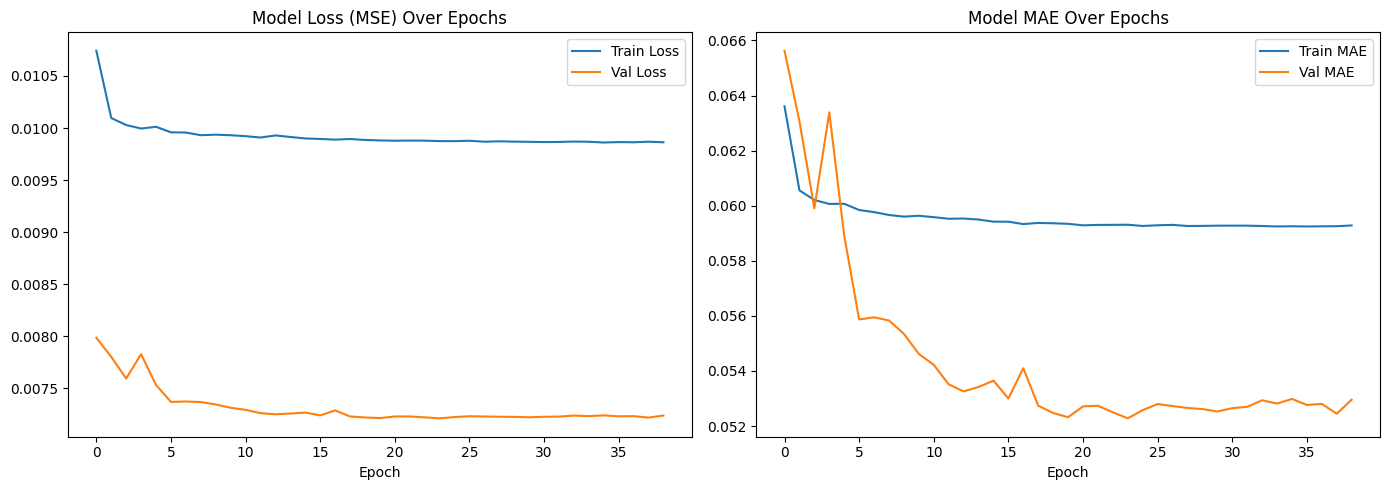

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE) Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. LSTM Evaluation on Test Set

In [18]:
lstm_preds_scaled = lstm_model.predict(X_test_seq).flatten()

lstm_mae = mean_absolute_error(y_test_seq, lstm_preds_scaled)
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_preds_scaled))
lstm_r2 = r2_score(y_test_seq, lstm_preds_scaled)

print(f"LSTM — MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R²: {lstm_r2:.4f}")

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM — MAE: 0.0507, RMSE: 0.0831, R²: 0.0016


## 8. Model Comparison

               Model       MAE      RMSE        R2
0  Linear Regression  0.025321  0.051159  0.633965
1      Random Forest  0.028505  0.056626  0.551553
2               LSTM  0.050698  0.083081  0.001595


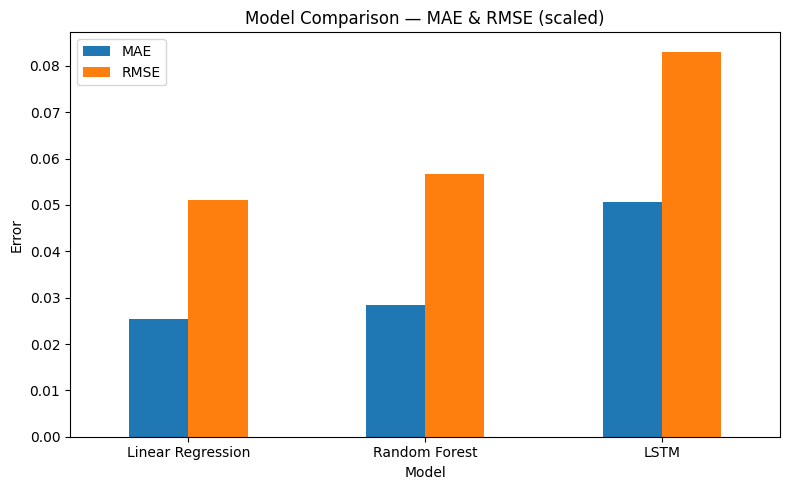

In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE': [lr_mae, rf_mae, lstm_mae],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse],
    'R2': [lr_r2, rf_r2, lstm_r2]
})
print(results)

results.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison — MAE & RMSE (scaled)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
print("Actual values — mean:", y_test_seq.mean(), "std:", y_test_seq.std())
print("Predicted values — mean:", lstm_preds_scaled.mean(), "std:", lstm_preds_scaled.std())
print("\nFirst 10 actual:", y_test_seq[:10])
print("First 10 predicted:", lstm_preds_scaled[:10])

Actual values — mean: 0.07989882316616984 std: 0.08314699377542696
Predicted values — mean: 0.08703507 std: 0.010164434

First 10 actual: [0.39252336 0.27102804 0.28037383 0.26168224 0.27102804 0.21495327
 0.14018692 0.07476636 0.05607477 0.06542056]
First 10 predicted: [0.08912689 0.08912689 0.08912689 0.08912689 0.08912689 0.08912689
 0.08912689 0.08912689 0.08912689 0.08912689]


In [20]:
print("Any NaN in X_train_seq?", np.isnan(X_train_seq).any())
print("Any NaN in X_test_seq?", np.isnan(X_test_seq).any())
print("X_train_seq min/max:", X_train_seq.min(), X_train_seq.max())


Any NaN in X_train_seq? False
Any NaN in X_test_seq? False
X_train_seq min/max: 0.0 85800.0


In [22]:
# Reload the RAW (unscaled) processed data to redo target scaling properly
train_raw = pd.read_csv('../data/processed/train_final.csv', parse_dates=['date'])
test_raw = pd.read_csv('../data/processed/test_final.csv', parse_dates=['date'])

# Load the target scaler to inverse the already-scaled Appliances column back to real Wh
import joblib
target_scaler_old = joblib.load('../models/target_scaler.pkl')

appliances_real_train = target_scaler_old.inverse_transform(train_raw[['Appliances']]).flatten()
appliances_real_test = target_scaler_old.inverse_transform(test_raw[['Appliances']]).flatten()

# Apply log1p transform (handles skew, log(1+x) so it's safe for zero values too)
appliances_log_train = np.log1p(appliances_real_train)
appliances_log_test = np.log1p(appliances_real_test)

# Re-scale the LOG values with a fresh MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
log_target_scaler = MinMaxScaler()
train_raw['Appliances'] = log_target_scaler.fit_transform(appliances_log_train.reshape(-1,1))
test_raw['Appliances'] = log_target_scaler.transform(appliances_log_test.reshape(-1,1))

print("New target range - train:", train_raw['Appliances'].min(), "to", train_raw['Appliances'].max())
print("Skew before:", pd.Series(appliances_real_train).skew(), "| Skew after log:", pd.Series(appliances_log_train).skew())

New target range - train: 0.0 to 0.9999999999999999
Skew before: 3.3215438173496024 | Skew after log: 1.1513762363662496


In [23]:
X_train2 = train_raw[feature_cols].values
y_train2 = train_raw['Appliances'].values
X_test2 = test_raw[feature_cols].values
y_test2 = test_raw['Appliances'].values

X_train_seq2, y_train_seq2 = create_sequences(X_train2, y_train2, LOOKBACK)
X_test_seq2, y_test_seq2 = create_sequences(X_test2, y_test2, LOOKBACK)

print(X_train_seq2.shape, y_train_seq2.shape)

(15776, 6, 24) (15776,)


In [24]:
tf.random.set_seed(42)

lstm_model2 = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, X_train_seq2.shape[2])),
    Dropout(0.1),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stop2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history2 = lstm_model2.fit(
    X_train_seq2, y_train_seq2,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop2],
    verbose=1
)

Epoch 1/100


C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0272 - mae: 0.1202 - val_loss: 0.0166 - val_mae: 0.1010
Epoch 2/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0221 - mae: 0.1117 - val_loss: 0.0165 - val_mae: 0.1004
Epoch 3/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0219 - mae: 0.1112 - val_loss: 0.0161 - val_mae: 0.0979
Epoch 4/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0218 - mae: 0.1109 - val_loss: 0.0159 - val_mae: 0.0962
Epoch 5/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0218 - mae: 0.1109 - val_loss: 0.0158 - val_mae: 0.0954
Epoch 6/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0217 - mae: 0.1108 - val_loss: 0.0157 - val_mae: 0.0945
Epoch 7/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0217 - mae: 0.1108 - val_loss: 0.0156 - val_mae: 0.0937
Epoch 8/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0217 - mae: 0.1107 - val_loss: 0.0157 - val_mae: 0.0948
Epoch 9/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss:

In [25]:
print("Feature columns and their ranges:")
for col in feature_cols:
    print(f"{col}: min={train_df[col].min():.4f}, max={train_df[col].max():.4f}")

Feature columns and their ranges:
Appliances_lag_10min: min=0.0000, max=1.0000
Appliances_roll_1h: min=0.0156, max=0.6636
Appliances_lag_30min: min=0.0000, max=1.0000
Appliances_lag_1h: min=0.0000, max=1.0000
Appliances_roll_3h: min=0.0218, max=0.4252
NSM: min=0.0000, max=85800.0000
RH_1: min=0.0195, max=1.0000
T4: min=0.0000, max=0.7802
Press_mm_hg: min=0.0000, max=1.0000
T8: min=0.0000, max=0.8142
T6: min=0.0000, max=0.7962
RH_5: min=0.0834, max=1.0000
T1_RH1_interaction: min=0.0000, max=0.5589
T3: min=0.0000, max=0.8641
RH_out: min=0.0921, max=1.0000
RH_2: min=0.1490, max=1.0000
RH_6: min=0.0000, max=1.0000
Windspeed: min=0.0000, max=1.0000
Visibility: min=0.0000, max=1.0000
RH_9: min=0.0000, max=1.0000
lights: min=0.0000, max=1.0000
hour: min=0.0000, max=23.0000
day_of_week: min=0.0000, max=6.0000
is_weekend: min=0.0000, max=1.0000


In [26]:
from sklearn.preprocessing import MinMaxScaler

cols_to_fix = ['NSM', 'hour', 'day_of_week']

for col in cols_to_fix:
    col_scaler = MinMaxScaler()
    train_df[col] = col_scaler.fit_transform(train_df[[col]])
    test_df[col] = col_scaler.transform(test_df[[col]])

# Verify
for col in cols_to_fix:
    print(f"{col}: train min={train_df[col].min():.4f}, max={train_df[col].max():.4f}")

# Rebuild X/y arrays with corrected columns
X_train = train_df[feature_cols].values
y_train = train_df['Appliances'].values
X_test = test_df[feature_cols].values
y_test = test_df['Appliances'].values

# Rebuild sequences
X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, LOOKBACK)

print("\nFull X_train_seq min/max:", X_train_seq.min(), X_train_seq.max())

NSM: train min=0.0000, max=1.0000
hour: train min=0.0000, max=1.0000
day_of_week: train min=0.0000, max=1.0000

Full X_train_seq min/max: 0.0 1.0


## 9. Bug Fix — Unscaled Time Features

Initial LSTM training collapsed to predicting a near-constant value (predicted std ≈ 0.01 vs actual std ≈ 0.08). 
Root cause: `NSM`, `hour`, and `day_of_week` were engineered *after* the Min-Max scaling step in Day 3, 
so they remained unscaled (NSM ranged 0–85,800 vs all other features in 0–1). This single dominant-scale 
feature destabilized LSTM training. Fixed by scaling these three columns separately with MinMaxScaler 
before rebuilding sequences and retraining.

## 10. LSTM Model — Retrained with Corrected Scaling

In [27]:
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape              ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                     │ (None, 6, 64)             │         22,784 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_4 (Dropout)               │ (None, 6, 64)             │              0 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ lstm_7 (LSTM)                     │ (None, 32)                │         12,416 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_5 (Dropout)               │ (None, 32)                │              0 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_6 (Dense)                   │ (None, 16)                │            528 │
├───────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_7 (Dense)                   │ (None, 1)                 │             17 │
└───────────────────────────────────┴───────────────────────────┴────────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0084 - mae: 0.0511 - val_loss: 0.0061 - val_mae: 0.0477
Epoch 2/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0073 - mae: 0.0460 - val_loss: 0.0053 - val_mae: 0.0410
Epoch 3/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0067 - mae: 0.0430 - val_loss: 0.0052 - val_mae: 0.0391
Epoch 4/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0064 - mae: 0.0415 - val_loss: 0.0050 - val_mae: 0.0387
Epoch 5/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0063 - mae: 0.0407 - val_loss: 0.0051 - val_mae: 0.0393
Epoch 6/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0062 - mae: 0.0400 - val_loss: 0.0047 - val_mae: 0.0346
Epoch 7/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0060 - mae: 0.0396 - val_loss: 0.0047 - val_mae: 0.0359
Epoch 8/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0058 - mae: 0.0390 - val_loss: 0.0048 - val_mae: 0.0375
Epoch 9/100
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/

## Training History Visualization

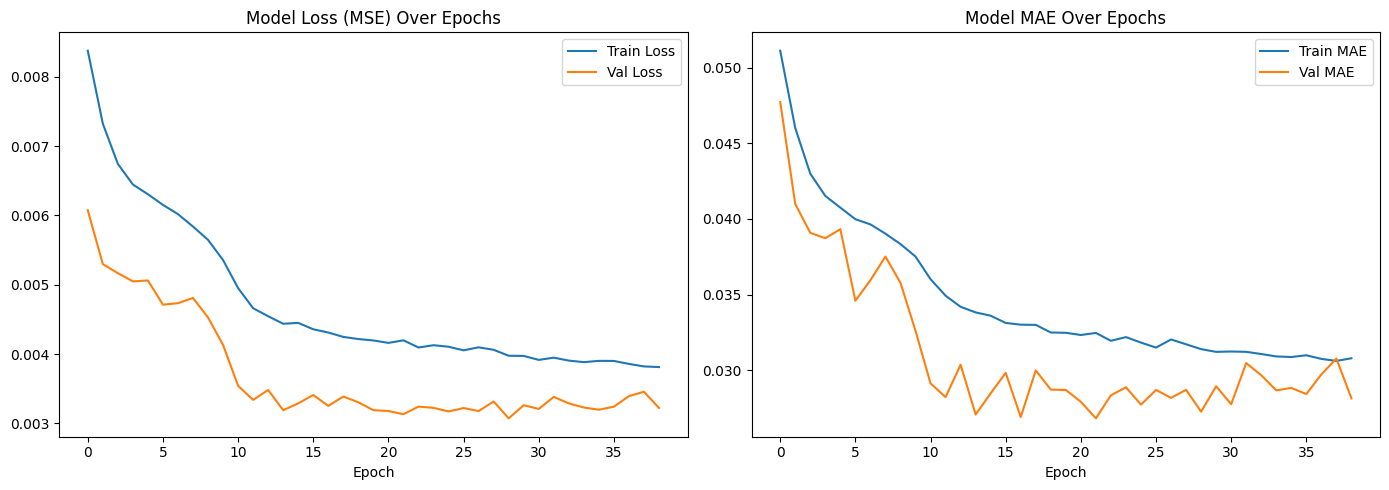

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE) Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/06_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Corrected LSTM — Evaluation on Test Set

In [29]:
lstm_preds_scaled = lstm_model.predict(X_test_seq).flatten()

lstm_mae = mean_absolute_error(y_test_seq, lstm_preds_scaled)
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_preds_scaled))
lstm_r2 = r2_score(y_test_seq, lstm_preds_scaled)

print(f"LSTM — MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R²: {lstm_r2:.4f}")
print("\nPredicted std:", lstm_preds_scaled.std(), "(should be close to actual std:", y_test_seq.std(), ")")

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM — MAE: 0.0302, RMSE: 0.0588, R²: 0.4994

Predicted std: 0.07696036 (should be close to actual std: 0.08314699377542696 )


## 12. Final Model Comparison

               Model       MAE      RMSE        R2
0  Linear Regression  0.025321  0.051159  0.633965
1      Random Forest  0.028505  0.056626  0.551553
2   LSTM (corrected)  0.030170  0.058830  0.499383


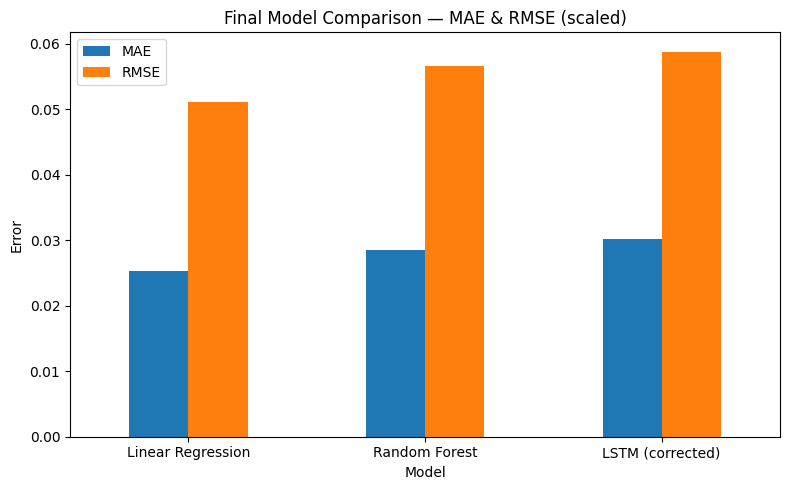

In [39]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM (corrected)'],
    'MAE': [lr_mae, rf_mae, lstm_mae],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse],
    'R2': [lr_r2, rf_r2, lstm_r2]
})
print(results)

results.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title('Final Model Comparison — MAE & RMSE (scaled)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Converting Predictions to Real Watt-hours

In [31]:
target_scaler = joblib.load('../models/target_scaler.pkl')

# Inverse transform actual and predicted values back to real Wh
y_test_real = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
lstm_preds_real = target_scaler.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()

# Real-world metrics
lstm_mae_real = mean_absolute_error(y_test_real, lstm_preds_real)
lstm_rmse_real = np.sqrt(mean_squared_error(y_test_real, lstm_preds_real))

print(f"LSTM (real Wh) — MAE: {lstm_mae_real:.2f} Wh, RMSE: {lstm_rmse_real:.2f} Wh")
print(f"\nFor context — average Appliances consumption: {y_test_real.mean():.2f} Wh")

LSTM (real Wh) — MAE: 32.28 Wh, RMSE: 62.95 Wh

For context — average Appliances consumption: 95.49 Wh


## 14. Predicted vs Actual Visualization

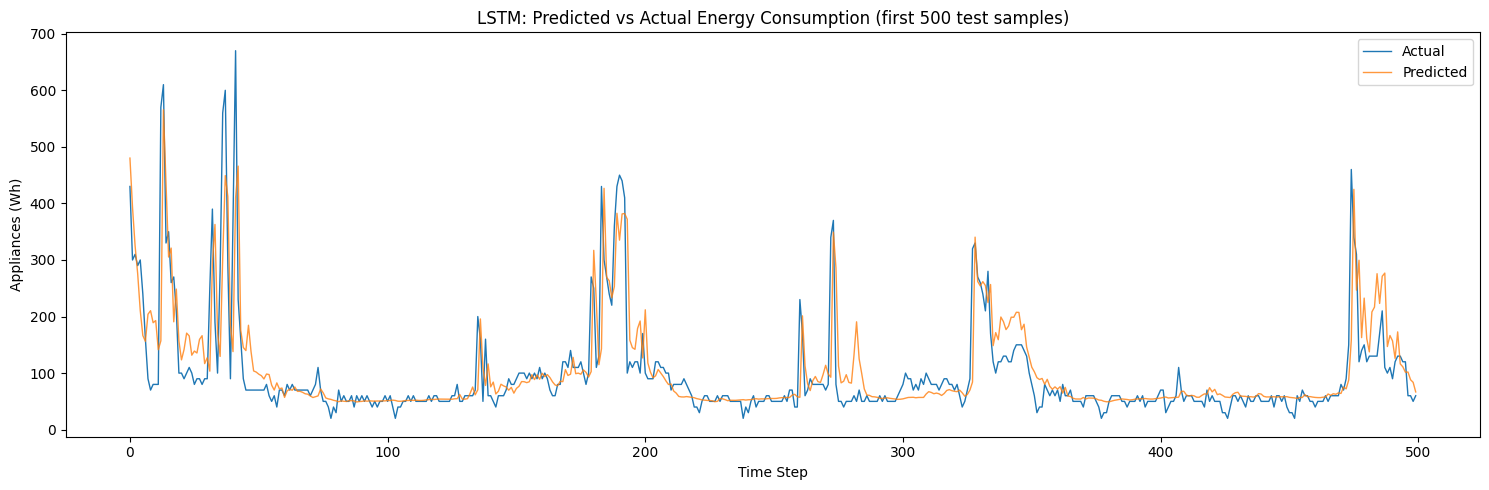

In [40]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_real[:500], label='Actual', linewidth=1)
plt.plot(lstm_preds_real[:500], label='Predicted', linewidth=1, alpha=0.8)
plt.title('LSTM: Predicted vs Actual Energy Consumption (first 500 test samples)')
plt.xlabel('Time Step')
plt.ylabel('Appliances (Wh)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Residual Analysis

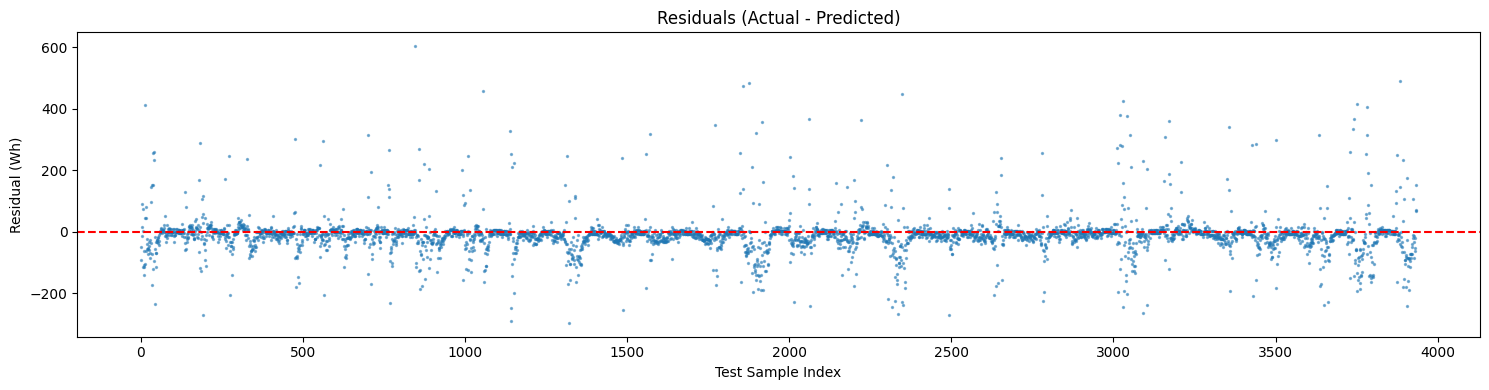

In [41]:
residuals = y_test_real - lstm_preds_real

plt.figure(figsize=(15, 4))
plt.scatter(range(len(residuals)), residuals, s=2, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals (Actual - Predicted)')
plt.xlabel('Test Sample Index')
plt.ylabel('Residual (Wh)')
plt.tight_layout()
plt.savefig('../reports/figures/09_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Hyperparameter Tuning — Comparing Configurations

In [34]:
def build_and_train_lstm(lstm_units1, lstm_units2, dropout_rate, learning_rate, label):
    tf.random.set_seed(42)
    model = Sequential([
        LSTM(lstm_units1, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, X_train_seq.shape[2])),
        Dropout(dropout_rate),
        LSTM(lstm_units2, activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    hist = model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=100,
                      batch_size=32, callbacks=[es], verbose=0)
    
    preds = model.predict(X_test_seq, verbose=0).flatten()
    mae = mean_absolute_error(y_test_seq, preds)
    rmse = np.sqrt(mean_squared_error(y_test_seq, preds))
    r2 = r2_score(y_test_seq, preds)
    
    print(f"{label} — epochs run: {len(hist.history['loss'])}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    return model, mae, rmse, r2

# Try 3 configurations
model_a, mae_a, rmse_a, r2_a = build_and_train_lstm(64, 32, 0.2, 0.001, "Config A (original)")
model_b, mae_b, rmse_b, r2_b = build_and_train_lstm(128, 64, 0.3, 0.0005, "Config B (bigger, slower LR)")
model_c, mae_c, rmse_c, r2_c = build_and_train_lstm(32, 16, 0.1, 0.001, "Config C (smaller, faster)")

C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config A (original) — epochs run: 28, MAE: 0.0270, RMSE: 0.0565, R²: 0.5377


C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config B (bigger, slower LR) — epochs run: 34, MAE: 0.0278, RMSE: 0.0582, R²: 0.5105


C:\Users\USER\Desktop\appliance-energy-prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Config C (smaller, faster) — epochs run: 27, MAE: 0.0278, RMSE: 0.0579, R²: 0.5148


## 17. Final Model Selection & Saving

In [35]:
final_model = model_a  # Config A is the winner 

# Re-run final evaluation to store official final numbers
final_preds_scaled = final_model.predict(X_test_seq, verbose=0).flatten()
final_mae = mean_absolute_error(y_test_seq, final_preds_scaled)
final_rmse = np.sqrt(mean_squared_error(y_test_seq, final_preds_scaled))
final_r2 = r2_score(y_test_seq, final_preds_scaled)

# Real-world Wh metrics
final_preds_real = target_scaler.inverse_transform(final_preds_scaled.reshape(-1,1)).flatten()
final_mae_real = mean_absolute_error(y_test_real, final_preds_real)
final_rmse_real = np.sqrt(mean_squared_error(y_test_real, final_preds_real))

print(f"FINAL MODEL — Scaled: MAE={final_mae:.4f}, RMSE={final_rmse:.4f}, R²={final_r2:.4f}")
print(f"FINAL MODEL — Real Wh: MAE={final_mae_real:.2f} Wh, RMSE={final_rmse_real:.2f} Wh")

# Save the model
final_model.save('../models/trained_model.h5')
print("\nModel saved to models/trained_model.h5")

FINAL MODEL — Scaled: MAE=0.0270, RMSE=0.0565, R²=0.5377
FINAL MODEL — Real Wh: MAE=28.92 Wh, RMSE=60.49 Wh

Model saved to models/trained_model.h5
